# Using SPArrOW with a retrained Cellpose model

In this tutorial, we will retrain a Cellpose model using our own manually segmented cells to improve its performance on irregularly shaped cells, such as Kupffer cells. Training your own cellpose model is covered in Cellpose2.0, for which you can find the paper [here](https://www.nature.com/articles/s41592-022-01663-4), and the code [here](https://github.com/MouseLand/cellpose/blob/v2.3.2/notebooks/run_cellpose_2.ipynb).

In [ ]:
import skimage.feature as features
import geopandas
from rasterio import features
import shapely
import spatialdata as sd
import napari
import numpy as np
import sparrow as sp
from tifffile import imwrite, imsave, imsave, imread
import os
import numpy as np
from cellpose import io, models
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
import geopandas as gpd
import tempfile

/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
the value of the environment variable BASIC_DCT_BACKEND is not in ["JAX","SCIPY"]
2026-01-20 14:41:38,017 - sparrow.plot._qc_cells - WARNING - 'joypy' not installed, to use 'sparrow.pl.ridgeplot_ch

# 1. Using a pretrained Cellpose model

In [ ]:
# Read in the data
sample = 'RESOLVE_PROTEIN_C1-1'
path=tempfile.gettempdir() # Change this to where your sdata file is stored

sdata = sd.read_zarr(path)
sdata

2026-01-20 15:15:46,314 [INFO] root_attr: channels_metadata
2026-01-20 15:15:46,314 [INFO] root_attr: multiscales
2026-01-20 15:15:46,315 [INFO] datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}]
2026-01-20 15:15:46,318 [INFO] resolution: 0
2026-01-20 15:15:46,319 [INFO]  - shape ('c', 'y', 'x') = (1, 17152, 17152)
2026-01-20 15:15:46,319 [INFO]  - chunks =  ['1', '17152', '17152']
2026-01-20 15:15:46,320 [INFO]  - dtype = uint16
2026-01-20 15:15:46,326 [INFO] root_attr: channels_metadata
2026-01-20 15:15:46,326 [INFO] root_attr: multiscales
2026-01-20 15:15:46,327 [INFO] datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}]
2026-01-20 15:15:46,329 [INFO] resolution: 0
2026-01-20 15:15:46,330 [INFO]  - shape ('c', 'y', 'x') = (1, 17152, 17152)
2026-01-20 15:15:46,331 [INFO]  - chunks =  ['1', '8192 (+ 768)', '8192 (+ 768)']
2026-01-20 15:15:46,331 [INFO]  - dtype = uint16
2026-01-20 15:15:4

/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 1, which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


SpatialData object, with associated Zarr store: /srv/scratch/karenh/sparrow-revision/data/sdata_objects/RESOLVE_PROTEIN_C1-1/sdata.zarr
├── Images
│     ├── 'Clec4f': DataArray[cyx] (1, 17152, 17152)
│     ├── 'Clec4f_threshold': DataArray[cyx] (1, 17152, 17152)
│     ├── 'Laminin': DataArray[cyx] (1, 17152, 17152)
│     ├── 'alpha-Laminin': DataArray[cyx] (1, 21440, 17152)
│     ├── 'alpha-Laminin_2': DataArray[cyx] (1, 17152, 17152)
│     ├── 'clahe_2': DataArray[cyx] (1, 17152, 17152)
│     ├── 'clec4f_thres': DataArray[cyx] (1, 17152, 17152)
│     ├── 'min_max_filtered_2': DataArray[cyx] (1, 17152, 17152)
│     ├── 'raw_image': DataArray[cyx] (1, 17152, 17152)
│     ├── 'tiling_correction': DataArray[cyx] (1, 17152, 17152)
│     ├── 'tiling_correction_clec4f': DataArray[cyx] (1, 17152, 17152)
│     └── 'transcript_density': DataArray[cyx] (1, 17152, 17152)
├── Labels
│     ├── 'clec4f_custom_segmentation_mask': DataArray[yx] (2000, 2000)
│     ├── 'clec4f_segmentation_mask': DataAr

Let's first plot a crop of the staining we want to segment. For our dataset, this is Clec4f.

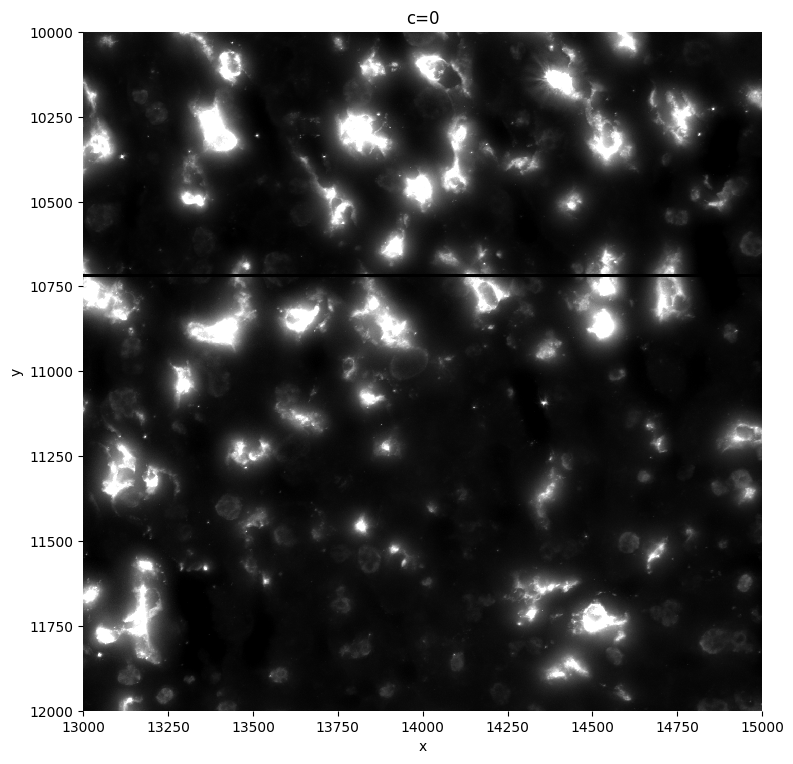

In [8]:
crd=[13000,15000,10000,12000]
sp.pl.plot_image(sdata, img_layer="Clec4f", crd=crd, figsize=(8, 8))

As a first step, we will segment the cells with a pretrained cellpose model. We will do this on a crop and adjust the parameters until we get the best segmentation possible.

/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
2026-01-20 14:37:15,986 - sparrow.image.segmentation._segmentation - INFO - Linking labels across chunks.
2026-01-20 14:37:15,996 - sparrow.image._manager - INFO - Writing results to layer 'clec4f_segmentation_mask'
/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
2026-01-20 14:37:16,454 - sparrow.utils._io - WARNING - layer with name 'clec4f_segmentation_mask' already exists. Overwriting...
/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compress

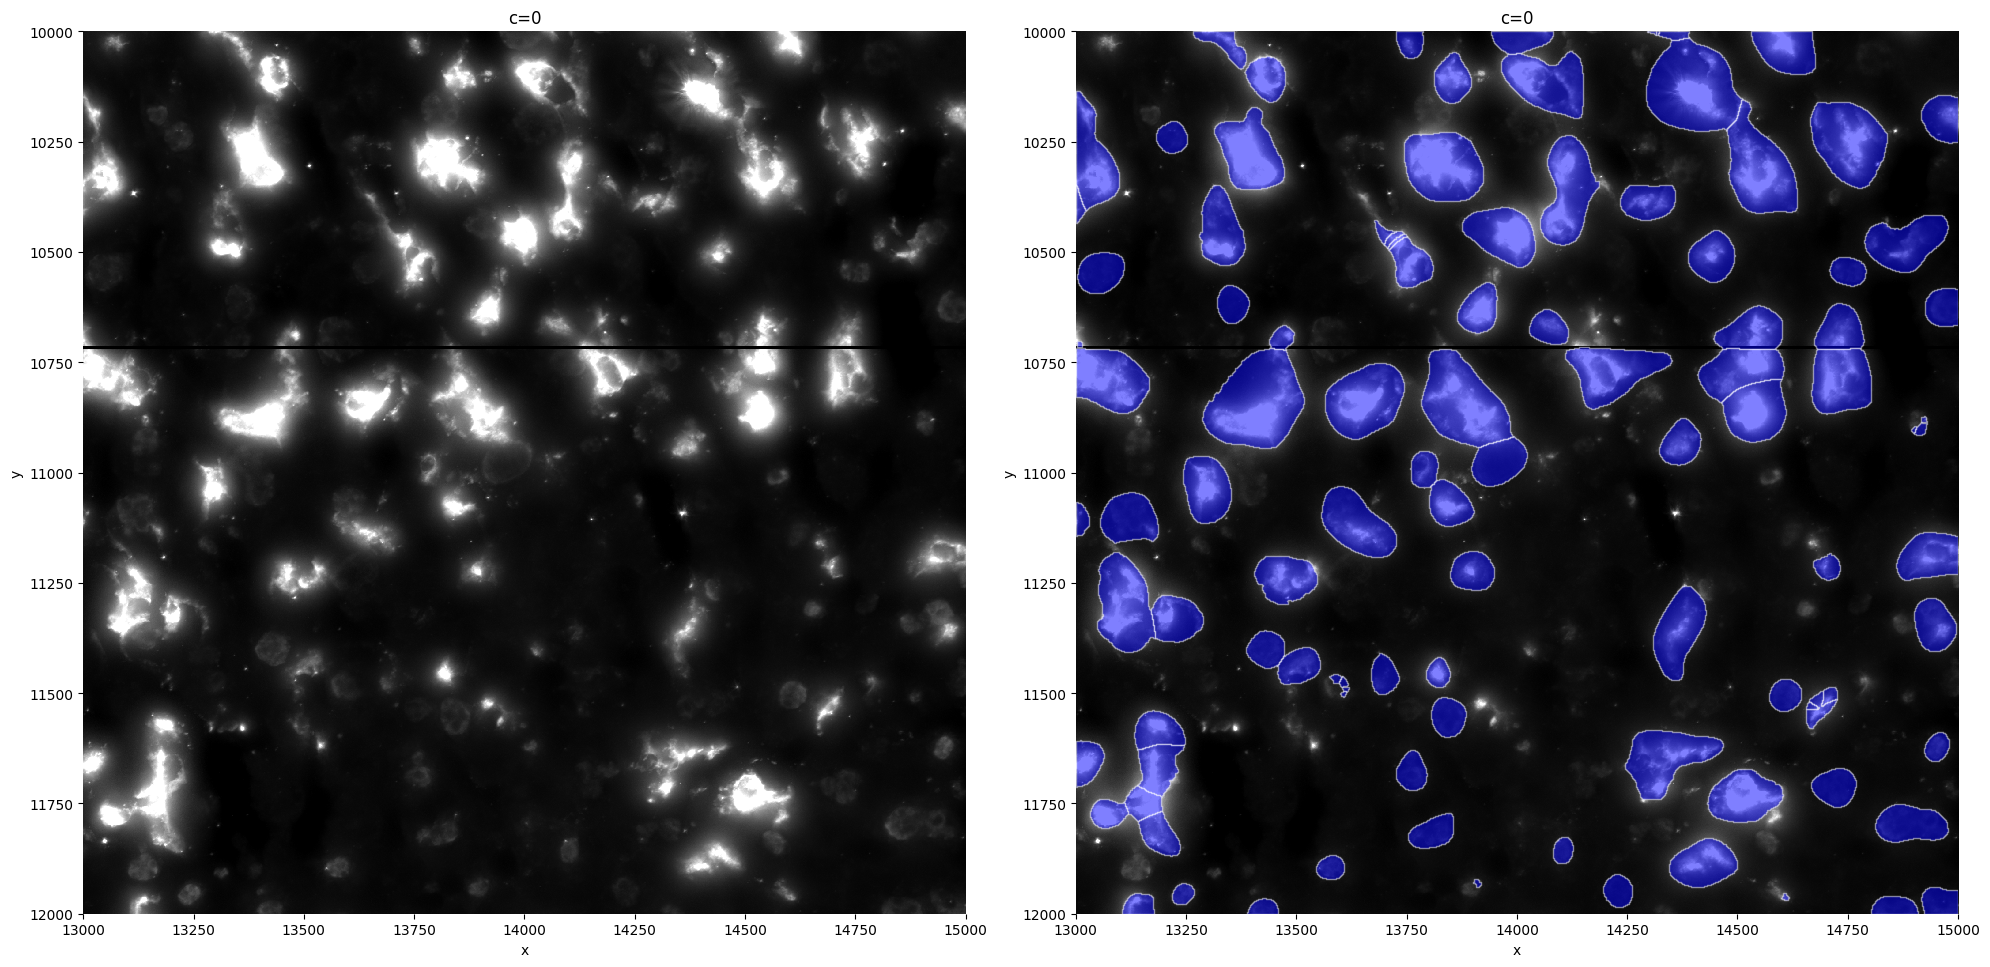

In [10]:
# Run the cellpose model, tune the flow_threshold, diameter, and cellprob_thresh parameters until you no longer get a better segmentation
# you can also try out different pretrained models of Cellpose
sdata = sp.im.segment(
    sdata=sdata,
    img_layer="Clec4f",
    output_labels_layer="clec4f_segmentation_mask",
    output_shapes_layer="clec4f_segmentation_mask_boundaries",
    crd=crd,
    flow_threshold=1.2,
    diameter=120,
    cellprob_threshold=-0.5,
    pretrained_model="cyto3", # we can choose here between ["cyto", "cyto2" ,"cyto3","nuclei","tissuenet_cp3", "livecell_cp3", "yeast_PhC_cp3", "yeast_BF_cp3", "bact_phase_cp3", "bact_fluor_cp3", "deepbacs_cp3", "scratch"]
    overwrite=True,
)

sp.pl.segment(sdata=sdata, crd=crd, img_layer="Clec4f", shapes_layer="clec4f_segmentation_mask_boundaries")

Segmentation mask from the cyto3 Cellpose model does not seem to fit our data, it segments a lot of noise and is not able to segment bigger, full kupffer cells. In this tutorial, we will retrain this model with some manually segmented cells in order to obtain a custom model for our dataset.

# 2. Acquiring the data for retraining

We will now manually segment cells using Napari. If you prefer not to create your own segmentations, we’ve included some pre-segmented example cells with this tutorial. In that case, you can skip ahead to [Section 3](#3-Retraining-the-Cellpose-model).


First we will prepare our file system to keep the manual segmentation and the retrained model nice and organized. 
If you have multiple different samples you want to segment and include in the retraining (either as a training or a testing set), repeat all the code in this section for every sample that you want to segment.

In [11]:
# Prepare how we will organize our segmentation files
sample = 'RESOLVE_PROTEIN_C1-1' # sample name, repeat this step for every sample if you have multiple samples available
output_dir = 'manual_segmentation'
os.makedirs(f'{output_dir}/models', exist_ok=True) # custom trained models will be saved in here
os.makedirs(f'{output_dir}/{sample}', exist_ok=True)
os.makedirs(f'{output_dir}/{sample}/train_dir', exist_ok=True)
f = open(f"{output_dir}/{sample}/coordinates.txt", "w") # will save the coordinates of the sections we segment in here, easy for reproducibility
f.close()

In [13]:
path=f"/srv/scratch/karenh/sparrow-revision/data/sdata_objects/{sample}/sdata.zarr" # Change this to where your sdata file is stored
sdata=sd.read_zarr(path)

/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 1, which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


Now we will open Napari and add our different images, shapes and point layers. The minimal requirement for retraining the model is the actual stain of the cells you want to segment, however, the other layers added below (DAPI image, annotated cell types and some marker genes) can help you (or the biological expert) in segmenting the cells.

In [ ]:
viewer = napari.Viewer() # open napari

In [ ]:
viewer.add_image(sdata['raw_image'])  # load in DAPI image
viewer.add_image(sdata['Clec4f'],colormap='red',blending='additive',name='kupffer cells')  # add Kupffer cells
# You will probably have to adjust the contrast limits in the napari window

/opt/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/napari/_vispy/layers/scalar_field.py:197: UserWarning: data shape (17152, 17152) exceeds GL_MAX_TEXTURE_SIZE 16384 in at least one axis and will be downsampled. Rendering is currently in 2D mode.
  warnings.warn(
/opt/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/napari/_vispy/layers/scalar_field.py:197: UserWarning: data shape (17152, 17152) exceeds GL_MAX_TEXTURE_SIZE 16384 in at least one axis and will be downsampled. Rendering is currently in 2D mode.
  warnings.warn(


<Image layer 'kupffer cells' at 0x3d3016350>

2025-11-25 15:54:23,822 [INFO] WARNING: MKL version on torch not working/installed - CPU version will be slightly slower.
2025-11-25 15:54:23,823 [INFO] see https://pytorch.org/docs/stable/backends.html?highlight=mkl
2025-11-25 15:54:23,850 [INFO] >>>> loading model /Users/karenh/Documents/projects/RetrainingCellpose/tutorial/models/custom_model
2025-11-25 15:54:23,911 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
2025-11-25 15:54:23,912 [INFO] >>>> model diam_labels =  100.762 (mean diameter of training ROIs)
2025-11-25 16:01:25,573 [INFO] WARNING: MKL version on torch not working/installed - CPU version will be slightly slower.
2025-11-25 16:01:25,574 [INFO] see https://pytorch.org/docs/stable/backends.html?highlight=mkl
2025-11-25 16:01:25,598 [INFO] >>>> loading model /Users/karenh/Documents/projects/RetrainingCellpose/tutorial/models/custom_model
2025-11-25 16:01:25,649 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during tr

In [9]:
# helper functions to plot cells in napari
def prepare_napari_plot(sdata,cutoff_shapes=0.5,shapes_layer='segmentation_mask_boundaries',output_layer='to_plot_napari'):
    '''create polygons instead of multipolygons and simplify the shapes so the plotting is faster.'''
    temp=sdata[shapes_layer].explode()
    temp['Area']=temp.area
    temp=temp.sort_values(by='Area',ascending=False)
    temp = temp[~temp.index.duplicated(keep='first')]
    if shapes_layer=='segmentation_mask_boundaries':
        temp=temp.reindex(sdata.table.obs.index)
    sdata[output_layer]=sd.models.ShapesModel.parse(temp)
    return sdata

def add_napari_layer(sdata,column=None,name=None,celltype=None,colormap='magma'):
    """
    Function to plot the cells into napari, colored by the correct olumn
    If you want a subset, just take a subset of the anndata before adding this. Don't use the function to change color, only to add an extra layer."""
    if celltype: 
        adata=sdata.table[sdata.table.obs['annotationKC1_KC2_Joint']==celltype,:]
        if not name:
            name=celltype
    else:
        adata=sdata.table
    coords_to_plot=[]
    to_color=None
    if column:
        if column + "_colors" in adata.uns:
                color_dict=dict(zip(adata.obs[column].cat.categories.values,adata.uns[column + "_colors"]))
                to_color=adata.obs[column].map(color_dict)
                print('colors from adata used')
    for i in sdata['to_plot_napari'].loc[adata.obs.index.values].geometry.exterior.simplify(tolerance=2):
        coords_to_plot.append(np.array(i.coords)[:,[1,0]]) 
    Columns=dict(zip(adata.var.index.values,adata.X.T))
    Columns.update(adata.obs.to_dict('list'))
    if not name:
        name=column
    if name in viewer.layers:
        viewer.layers[name].features=Columns
        if to_color:
            print('layer reused')
            viewer.layers[name].face_color=to_color.values
        if column in viewer.layers[name].features:
            print('layer reused')
            viewer.layers[name].face_color=column
            viewer.layers[name].face_colormap =colormap
    elif to_color is not None:
        viewer.add_shapes(coords_to_plot,name=name,shape_type='polygon',face_color=to_color.values.astype(str),opacity=0.7,edge_width=3,edge_color='white',features=Columns)
    elif column in Columns.keys():
        viewer.add_shapes(coords_to_plot,name=name,shape_type='polygon',face_color=column,opacity=0.7,edge_width=3,edge_color='white',features=Columns,face_colormap=colormap)
    elif column==None:
        viewer.add_shapes(coords_to_plot,name=name,shape_type='polygon',face_color=colormap,opacity=0.7,edge_width=3,edge_color='white',features=Columns)

def add_filtered_napari_layer(sdata,shapes_layer,color='red',name=None):
    """If you want a subset, just take a subset of the anndata before adding this. Don't use the function to change color, only to add an extra layer."""
    if not name:
        names=shapes_layer
    adata=sdata.table
    coords_to_plot=[]
    to_color=None
    for i in sdata[shapes_layer].geometry.exterior.simplify(tolerance=2):
        coords_to_plot.append(np.array(i.coords)[:,[1,0]]) 
    
    
    viewer.add_shapes(coords_to_plot,name=name,shape_type='polygon',face_color='transparent',opacity=0.4,edge_width=5,edge_color=color)  

In [ ]:
sdata=prepare_napari_plot(sdata) # prepare sdata object with helper functions to easily plot cells in Napari      
# add annotated cell types
add_napari_layer(sdata,celltype='KC1',colormap='red')
add_napari_layer(sdata,celltype='Stellate',colormap='yellow')
add_napari_layer(sdata,celltype='Endothelial',colormap='green')
add_napari_layer(sdata,celltype='Hepatocytes',colormap='orange')

/var/folders/7n/69n_rqrn76d5257ncsjk9ym80000gp/T/ipykernel_33234/539914861.py:9: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  temp=temp.reindex(sdata.table.obs.index)
/opt/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `to_plot_napari` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/var/folders/7n/69n_rqrn76d5257ncsjk9ym80000gp/T/ipykernel_33234/539914861.py:18: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  adata=sdata.table[sdata.table.obs['annotationKC1_KC2_Joint']==celltype,:]
/var/folders/7n/69n_rqrn76d5257ncsjk9ym80000gp/T/ipykernel_33234/539914861.py:18: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  adata=sdata.table[sdata.table.obs['annotationKC1_KC2_Joint']==celltype,:]

In [ ]:
# plot transcripts
df=sdata.points['transcripts'].compute()
Kc=['Clec4f', "Vsig4", 'Kcna2']
viewer.add_points(df[df['gene'].isin(Kc)][['y','x']].values,size=20,face_color='maroon',name='KC_genes')

<Points layer 'KC_genes' at 0x4616501c0>

/opt/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/napari/_vispy/layers/scalar_field.py:197: UserWarning: data shape (17152, 17152) exceeds GL_MAX_TEXTURE_SIZE 16384 in at least one axis and will be downsampled. Rendering is currently in 2D mode.
  warnings.warn(
AGX: exceeded compiled variants footprint limit


Now we can actally start segmenting!

1. **Create a new shapes layer**, you can rename it to segmentation or something similar.

<video width="1000" autoplay loop muted>
  <source src="media/segmentation_layer.mp4" type="video/mp4">
</video>

2. Use the **lasso tool** to manually segment the cells in your image. You can toggle on the different layers to help you in this process.

<video width="1000" autoplay loop muted>
  <source src="media/segmentation.mp4" type="video/mp4">
</video>

3. Once you’ve finished outlining the cells you want, we’ll save these segmentations as smaller **cropped regions** of the full image.

   * **Zoom in** on an area where you’ve completed the segmentation and make sure all visible cells are accurately outlined.
   * Each cropped region should contain **at least five segmented cells**.

4. **Run the function below** to save this cropped region. It will create three files:

   * `image_region_{nb}.tiff` → the cropped raw staining image,
   * `image_region_{nb}_masks.tiff` → the segmentation mask corresponding to that crop,
   * `region_{nb}.txt` → a text file storing the coordinates of the crop within the full image.

5. **Move to another area** of your image that contains more segmented cells.

   * Again, check that all visible cells in this new region are well segmented and that there are at least five.
   * Increase the `img_nb` value by 1 in the function and run it again to save the next cropped region.

Repeat this process to collect multiple cropped regions across your image — these will be used later to retrain the model.

<video width="1000" autoplay loop muted>
  <source src="media/saving.mp4" type="video/mp4">
</video>


In [ ]:
def save_manual_segmentation_napari(output_path, img_nb):
    # extract coordinates
    height, width = viewer.window.qt_viewer.viewer._get_viewbox_size()
    _, center_y, center_x = viewer.camera.center
    scale = 1 / viewer.camera.zoom
    dx = (width  / 2) * scale
    dy = (height / 2) * scale
    crd = [int(center_y - dy), int(center_y + dy), int(center_x - dx), int(center_x + dx)]

    # Save image without labels
    save_path_img = output_path + 'train_dir/image_region_' + str(img_nb) + '.tiff'
    imwrite(save_path_img,sdata['Clec4f'].values[0,crd[0]:crd[1],crd[2]:crd[3]])

    # Save labels
    save_path_label = output_path + 'train_dir/image_region_' + str(img_nb) + '_masks.tiff'
    Portal = viewer.layers['segmentation'].to_labels(labels_shape=sdata['raw_image'].shape)
    imwrite(save_path_label,Portal[0,crd[0]:crd[1],crd[2]:crd[3]])
    
    # save coordinates (for reproducibility)
    with open(f"{output_path}coordinates.txt", "a") as f:
        f.write(f'Crop nb {img_nb}: ')
        f.write(", ".join(map(str, crd)) + "\n")
        f.close()

In [113]:
# This will save the needed images and labels in the training directory, needed for the retraining function of Cellpose
# Make sure you shift the window in Napari each time to contain at least 5 labels (otherwise, cellpose won't use it for the retraining)
# change the img_nb each time you shift
# coordinates of the regions will also be saved in a txt file if needed afterwards
save_manual_segmentation_napari(output_path=f'{output_dir}/{sample}/', img_nb=3) 

/var/folders/7n/69n_rqrn76d5257ncsjk9ym80000gp/T/ipykernel_33234/769913528.py:3: FutureWarning: Public access to Window.qt_viewer is deprecated and will be removed in
v0.7.0. It is considered an "implementation detail" of the napari
application, not part of the napari viewer model. If your use case
requires access to qt_viewer, please open an issue to discuss.
  height, width = viewer.window.qt_viewer.viewer._get_viewbox_size()


[6087, 6978, 7559, 8743]


Finally, you can also save all your segmented cells in one geodataframe (might be useful for reproducibility).

In [114]:
import rasterio
def mask_to_polygons_layer(mask: np.ndarray) -> geopandas.GeoDataFrame:
    """Returns the polygons as GeoDataFrame

    This function converts the mask to polygons.
    https://rocreguant.com/convert-a-mask-into-a-polygon-for-images-using-shapely-and-rasterio/1786/
    """

    all_polygons = []
    all_values = []

    # Extract the polygons from the mask
    for shape, value in features.shapes(
        mask.astype(np.int32),
        mask=(mask > 0),
        transform=rasterio.Affine(1.0, 0, 0, 0, 1.0, 0),
    ):
        all_polygons.append(shapely.geometry.shape(shape))
        all_values.append(int(value))

    return geopandas.GeoDataFrame(dict(geometry=all_polygons), index=all_values)

In [116]:
shape=sdata['raw_image'].shape
Portal = viewer.layers['segmentation'].to_labels(labels_shape=shape)

imsave(f'{output_dir}/{sample}/Portal.tiff',Portal)

shapes_geo = mask_to_polygons_layer(Portal)
shapes_geo.to_file(f'{output_dir}/{sample}/shapes.geojson')

/var/folders/7n/69n_rqrn76d5257ncsjk9ym80000gp/T/ipykernel_33234/3213642603.py:4: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave(f'{output_dir}/{sample}/Portal.tiff',Portal)
/opt/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


# 3. Retraining the Cellpose model

Now we will use the manually segmented regions as input to retrain the Cellpose model. First we will load in all the image regions with their respective labels that we want to use as training set.

In [12]:
# samples that were manually segmented that need to be used for retraining (example here is using just one sample, but you could add multiple)
samples_to_include = ['RESOLVE_PROTEIN_C1-1']
output_dir='manual_segmentation'

In [13]:
all_images = []
all_labels = []
all_image_names = []

for sample in samples_to_include:
    train_dir = f"{output_dir}/{sample}/train_dir"
    # we are not working with testing images here, but this is also possible
    output = io.load_train_test_data(train_dir, test_dir=None, image_filter=None,
                                mask_filter="_masks", look_one_level_down=False)
    images, labels, image_names, test_images, test_labels, image_names_test = output
    for image in images:
        all_images.append(image)
    for label in labels:
        all_labels.append(label)
    for image_name in image_names:
        all_image_names.append(image_name)

Next, we specify which pretrained Cellpose model we want to start from, how we want to name our model, and any training parameters.

In [14]:
from cellpose import models

# model name and path
# Name of the pretrained model to start from and new model name:
initial_model = "cyto2" # ["cyto", "cyto2" ,"cyto3","nuclei","tissuenet_cp3", "livecell_cp3", "yeast_PhC_cp3", "yeast_BF_cp3", "bact_phase_cp3", "bact_fluor_cp3", "deepbacs_cp3", "scratch"]
model_name = f"custom_model"

# other parameters for training.
n_epochs =  100
Channel_to_use_for_training = "Grayscale" 
Second_training_channel= "None"

learning_rate = 0.1 
weight_decay = 0.0001 
  
# Here we check that no model with the same name already exist, if so delete
model_path = output_dir
if os.path.exists(model_path+'/'+model_name):
  print("!! WARNING: "+model_name+" already exists and will be deleted in the following cell !!")
  
test_dir = None

# Here we match the channel to number
if Channel_to_use_for_training == "Grayscale":
  chan = 0
elif Channel_to_use_for_training == "Blue":
  chan = 3
elif Channel_to_use_for_training == "Green":
  chan = 2
elif Channel_to_use_for_training == "Red":
  chan = 1


if Second_training_channel == "Blue":
  chan2 = 3
elif Second_training_channel == "Green":
  chan2 = 2
elif Second_training_channel == "Red":
  chan2 = 1
elif Second_training_channel == "None":
  chan2 = 0

Finally, we retrain the model with the train_seg function of Cellpose.

In [15]:
from cellpose import train 

# start logger (to see training across epochs)
logger = io.logger_setup()

train_data = all_images
train_labels = all_labels
# Can also subset data into training and testing set if needed
test_data = None
test_labels = None

# define cellpose model 
model = models.CellposeModel(model_type=initial_model)

# set channels
channels = [chan, chan2]

new_model_path, train_losses, test_losses = train.train_seg(model.net, train_data=train_data, 
                                                            train_labels=train_labels, 
                                                            test_data=test_data,
                                                            test_labels=test_labels,
                                                            channels=channels, 
                                                            save_path=model_path, 
                                                            n_epochs=n_epochs,
                                                            learning_rate=learning_rate, 
                                                            weight_decay=weight_decay, 
                                                            SGD=True,
                                                            nimg_per_epoch=8,
                                                            model_name=model_name,)

creating new log file
2026-01-20 15:09:30,736 [INFO] WRITING LOG OUTPUT TO /home/karenh/.cellpose/run.log
2026-01-20 15:09:30,737 [INFO] 
cellpose version: 	3.1.1.3 
platform:       	linux 
python version: 	3.10.19 
torch version:  	2.9.1+cu128
2026-01-20 15:09:30,738 [INFO] >> cyto2 << model set to be used
2026-01-20 15:09:30,739 [INFO] >>>> using CPU
2026-01-20 15:09:30,740 [INFO] >>>> using CPU
2026-01-20 15:09:31,018 [INFO] >>>> loading model /home/karenh/.cellpose/models/cyto2torch_0
2026-01-20 15:09:31,151 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
2026-01-20 15:09:31,153 [INFO] computing flows for labels


100%|██████████| 20/20 [00:47<00:00,  2.39s/it]

2026-01-20 15:10:19,051 [INFO] >>> computing diameters



100%|██████████| 20/20 [00:00<00:00, 455.07it/s]

2026-01-20 15:10:19,098 [WARNING] 1 train images with number of masks less than min_train_masks (5), removing from train set
2026-01-20 15:10:19,099 [INFO] >>> using channels [0, 0]
2026-01-20 15:10:19,100 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-01-20 15:10:19,331 [INFO] >>> n_epochs=100, n_train=19, n_test=None
2026-01-20 15:10:19,332 [INFO] >>> SGD, learning_rate=0.10000, weight_decay=0.00010, momentum=0.900
2026-01-20 15:10:20,368 [INFO] >>> saving model to manual_segmentation/models/custom_model
2026-01-20 15:10:23,710 [INFO] 0, train_loss=2.3558, test_loss=0.0000, LR=0.000000, time 3.34s
2026-01-20 15:10:36,070 [INFO] 5, train_loss=1.4121, test_loss=0.0000, LR=0.055556, time 15.70s
2026-01-20 15:10:49,198 [INFO] 10, train_loss=0.8371, test_loss=0.0000, LR=0.100000, time 28.83s
2026-01-20 15:11:15,261 [INFO] 20, train_loss=0.8976, test_loss=0.0000, LR=0.100000, time 54.89s
2026-01-20 15:11:41,316 [INFO] 30, train_loss=0.6845, test_loss=0.0000, LR=0.100000, time 80.95s
2026-01-20 15:12:06,763 [INFO] 40, train_loss=0.5728, test_loss=0.0000, LR=0.100000, time 106.39s
2026-01-20 15:12:33,048 [INFO] 50, train_loss=0.4579, test_loss=0.0000, LR=0.100000, time 132.68s
2026-01-20 15:12:59,189 [INFO] 60, train_loss=0.4255, test

We can now use this model to segment our Clec4f staining with SPArrOW.

/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
2026-01-20 15:17:02,266 - sparrow.image.segmentation._segmentation - INFO - Linking labels across chunks.
2026-01-20 15:17:02,274 - sparrow.image._manager - INFO - Writing results to layer 'clec4f_custom_segmentation_mask'
/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
2026-01-20 15:17:02,732 - sparrow.utils._io - WARNING - layer with name 'clec4f_custom_segmentation_mask' already exists. Overwriting...
/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_c

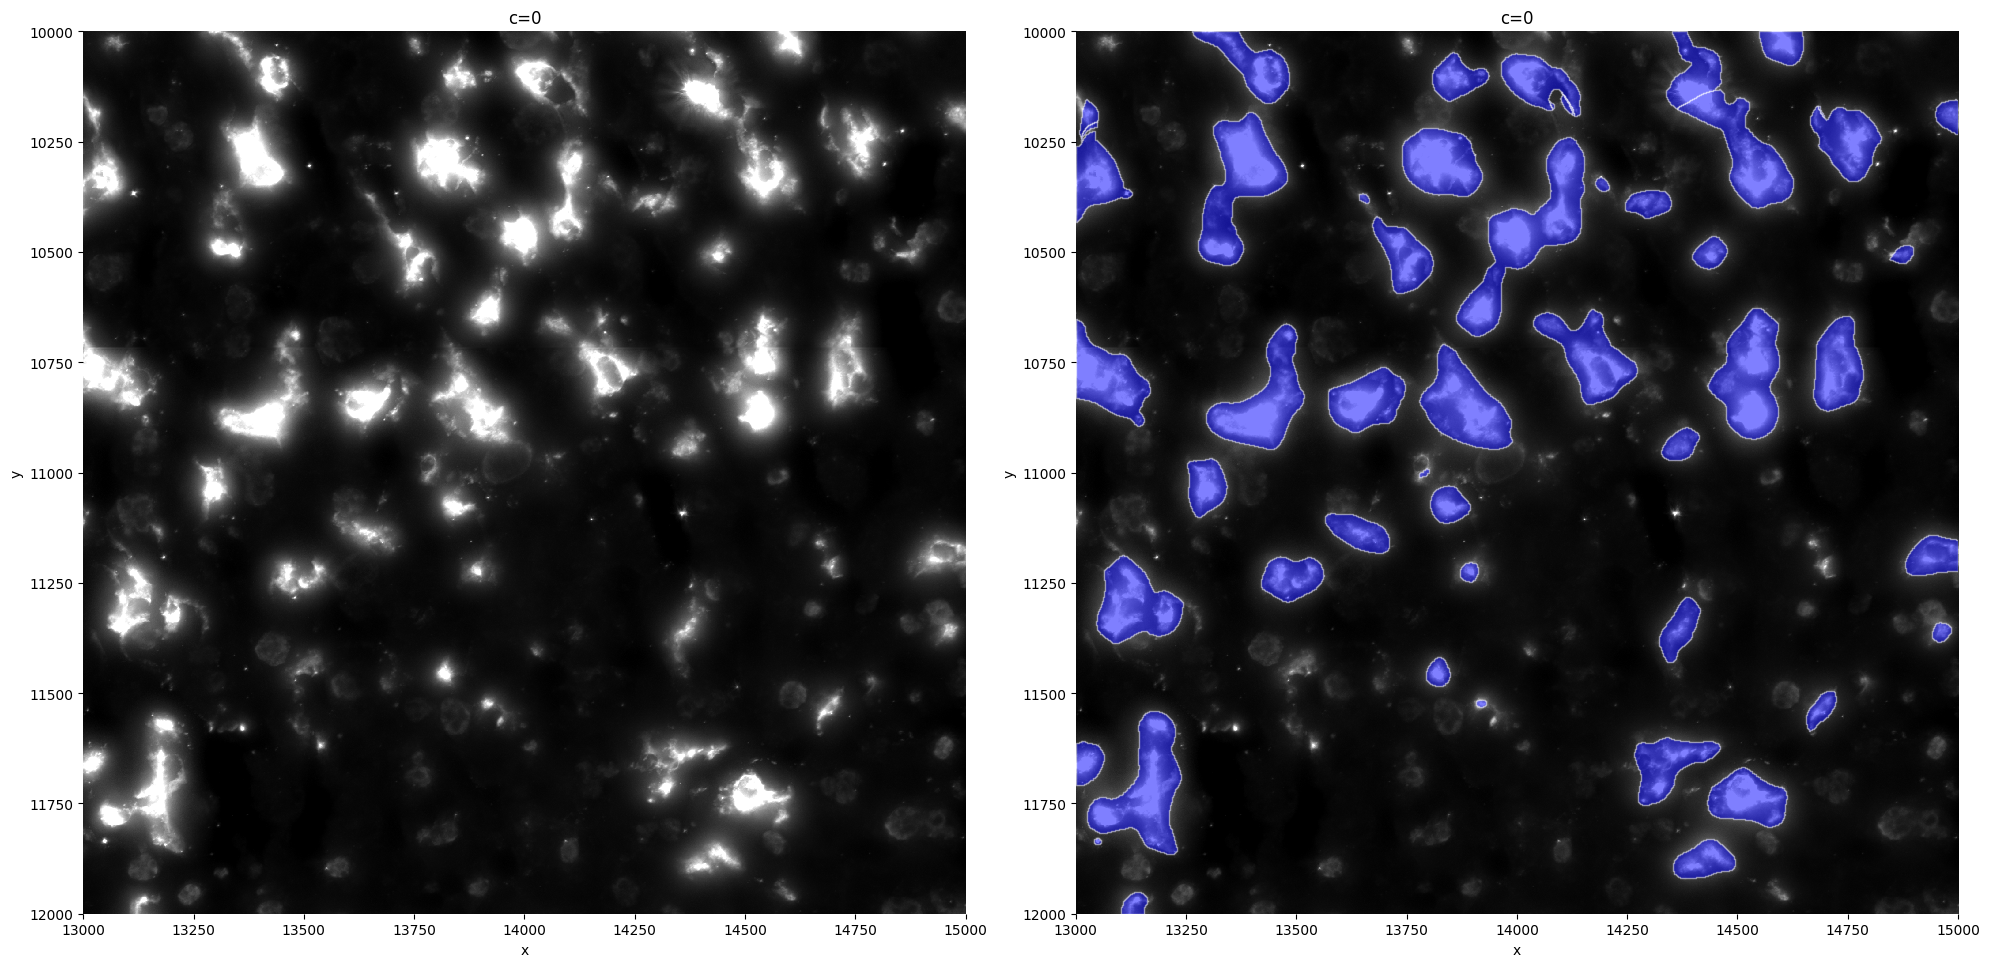

In [20]:
crd=[13000,15000,10000,12000]
sp.im.segment(sdata=sdata, 
              img_layer='tiling_correction_clec4f', 
              output_labels_layer='clec4f_custom_segmentation_mask',
              output_shapes_layer='clec4f_custom_segmentation_mask_boundaries',
              crd=crd,
              flow_threshold=1.2,
              diameter=140,
              cellprob_threshold=-0.5,
              pretrained_model='manual_segmentation/models/custom_model',
              overwrite=True)
sdata
sp.pl.segment(sdata=sdata, crd=crd, img_layer="tiling_correction_clec4f", shapes_layer="clec4f_custom_segmentation_mask_boundaries")

We can see that the model is segmenting the KC better and is not segmenting as much debris as before. However, some larger KCs are still split into multiple fragments instead of being captured as a single object. This can be corrected by merging the adjacent mask fragments.

In [21]:
import geopandas as gpd
from shapely.ops import unary_union
from shapely.geometry import Polygon
from shapely.affinity import scale

def merge_attached_cells_gdf(gdf, dilation_factor=1):
    dilated = gdf.geometry.apply(
        lambda geom: scale(geom, xfact=dilation_factor, yfact=dilation_factor, origin='centroid')
    )
    merged = unary_union(dilated)
    if merged.geom_type == "Polygon":
        merged_polys = [merged]
    else:
        merged_polys = list(merged.geoms)
    eroded = [
        scale(poly, xfact=1/dilation_factor, yfact=1/dilation_factor, origin='centroid')
        for poly in merged_polys
    ]
    return gpd.GeoDataFrame(geometry=eroded, crs=gdf.crs)


In [22]:
from spatialdata.models import ShapesModel
mask = sdata['clec4f_custom_segmentation_mask_boundaries']
closed_mask = merge_attached_cells_gdf(mask)
closed_mask.attrs["transform"] = mask.attrs["transform"]
sdata['clec4f_custom_segmentation_mask_boundaries'] = closed_mask

/srv/scratch/karenh/anaconda3/envs/napari-sparrow/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `clec4f_custom_segmentation_mask_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


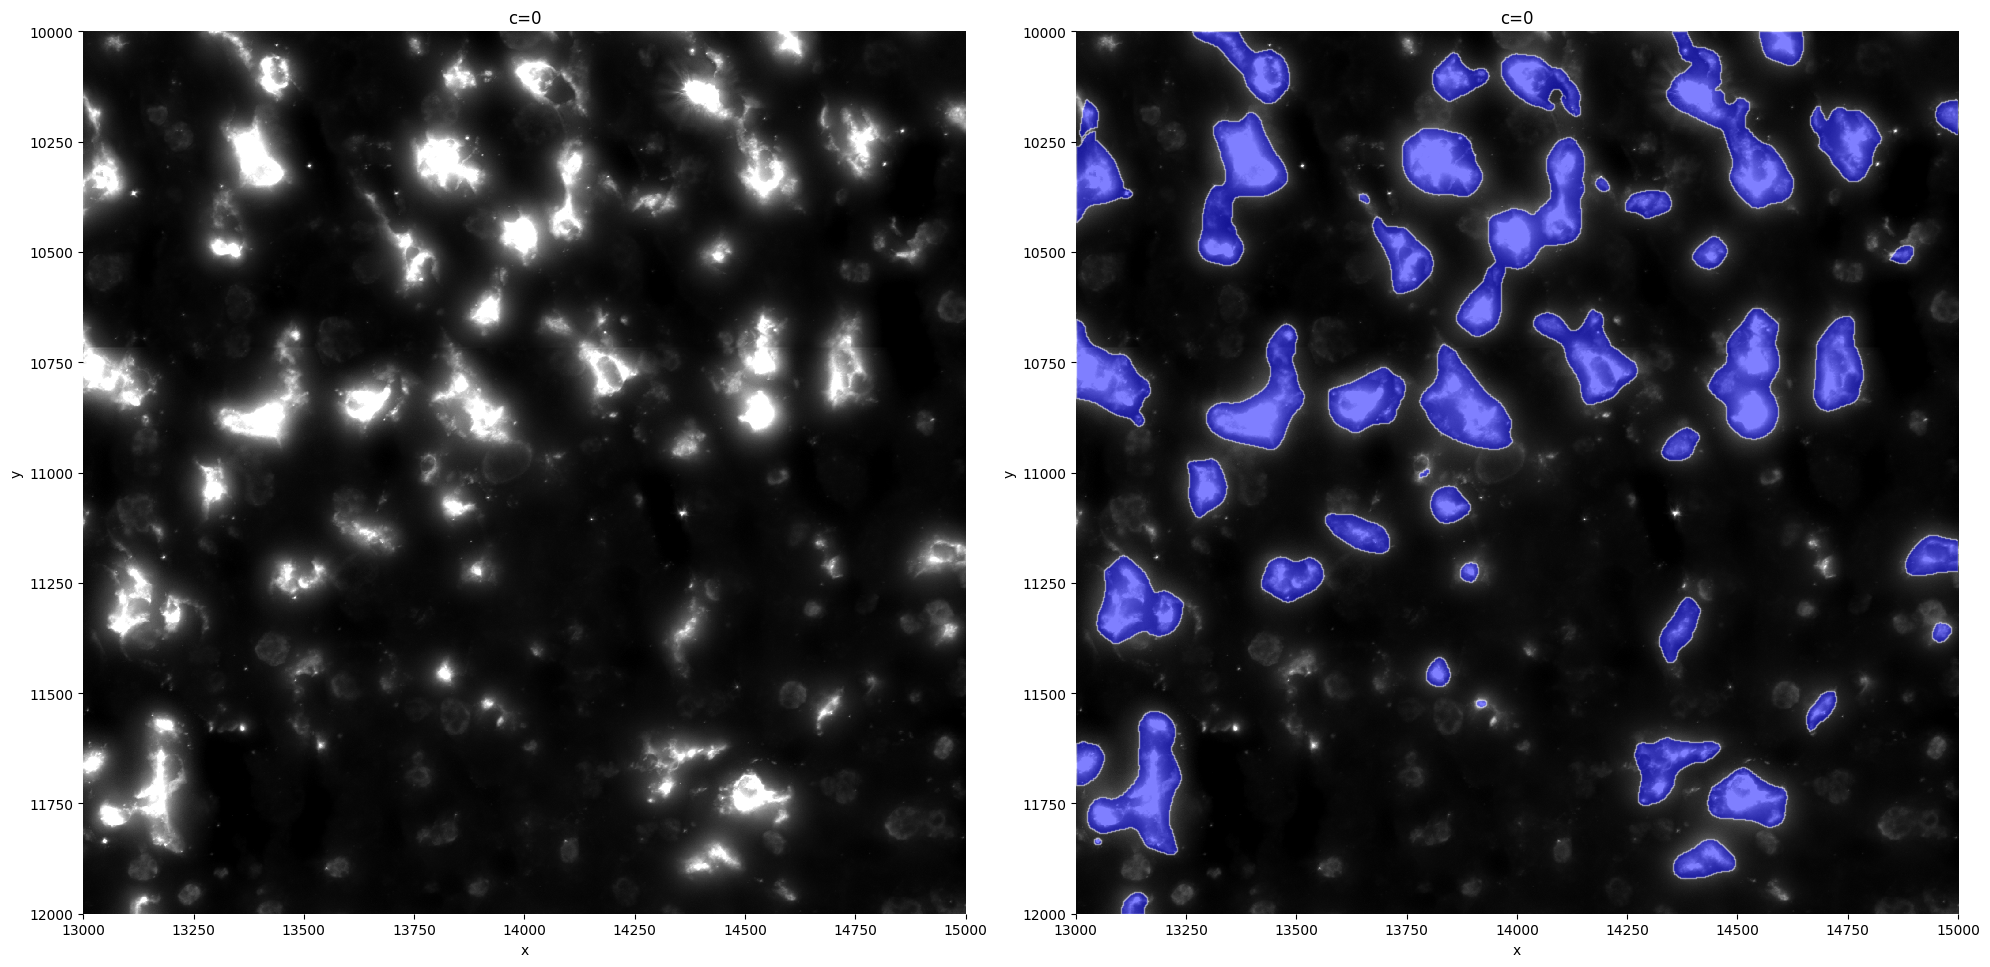

In [23]:
sp.pl.segment(sdata=sdata, crd=crd, img_layer="tiling_correction_clec4f", shapes_layer="clec4f_custom_segmentation_mask_boundaries")

Comparing it with the original Cellpose model segmentation, we can now see a lot of improvement.

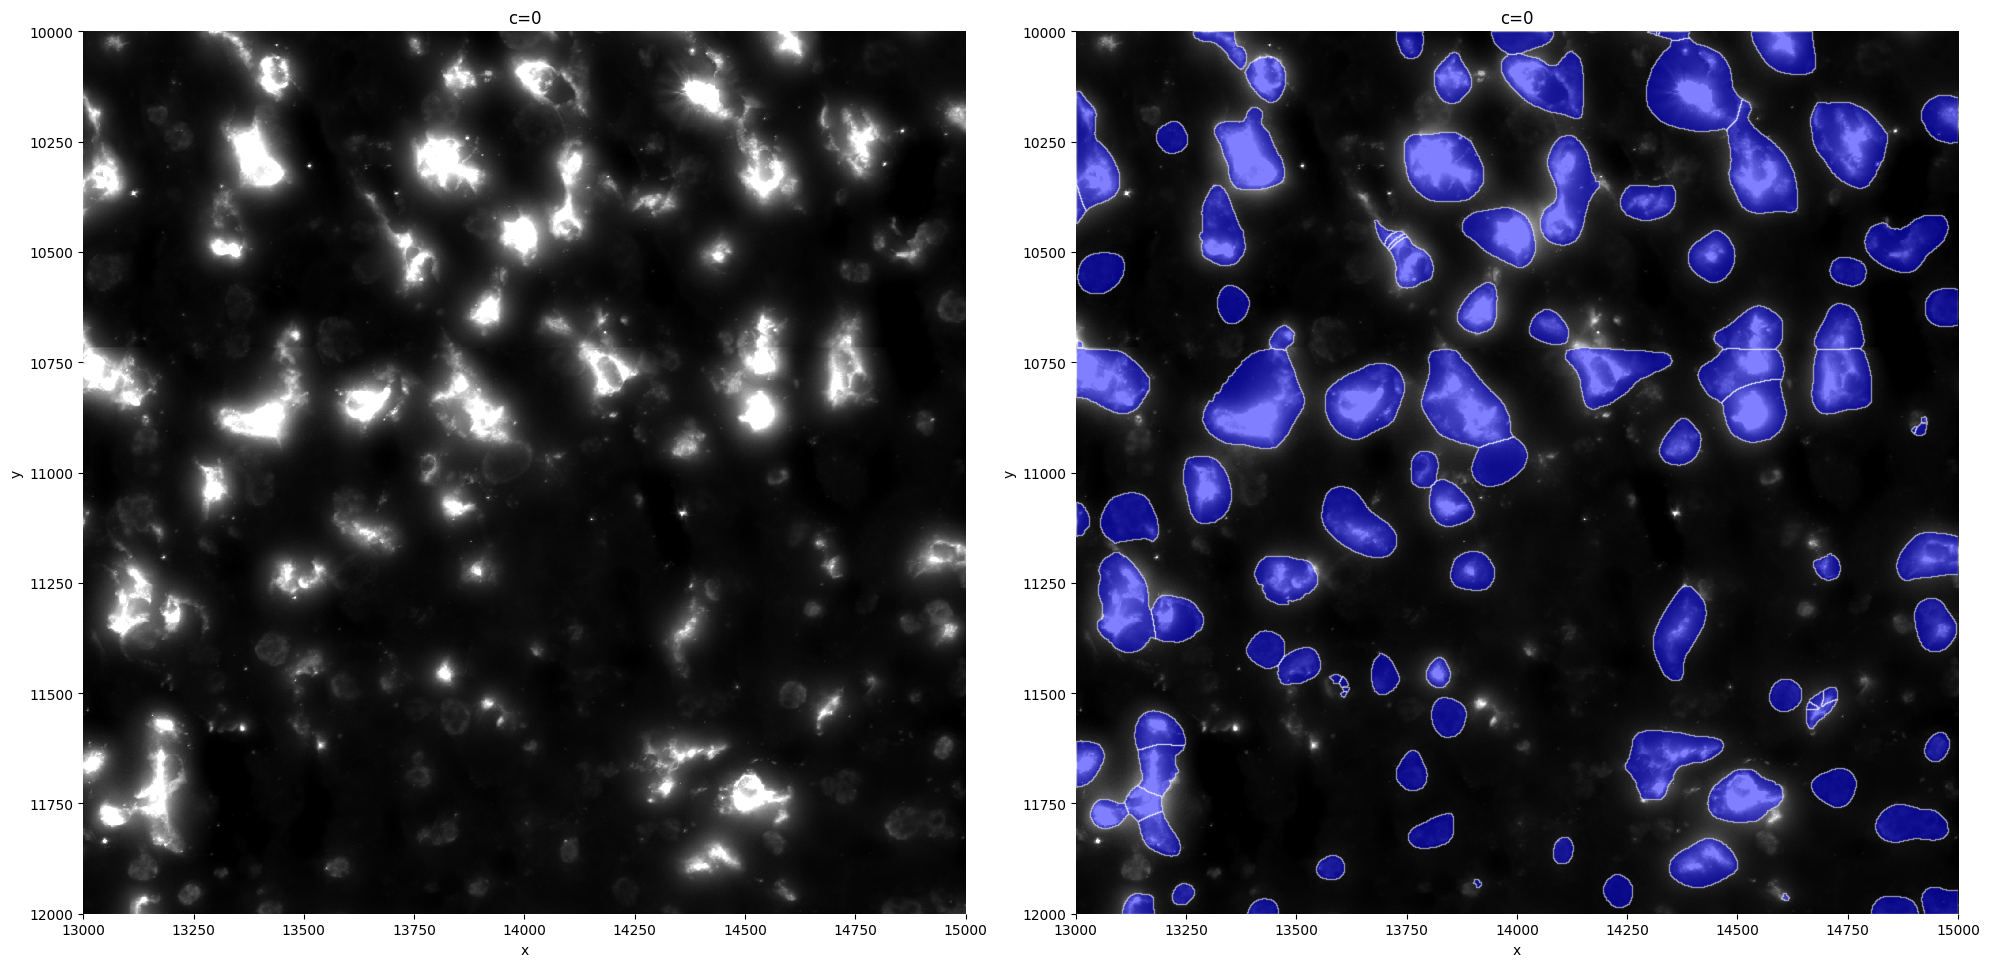

In [24]:
sp.pl.segment(sdata=sdata, crd=crd, img_layer="tiling_correction_clec4f", shapes_layer="clec4f_segmentation_mask_boundaries")